# LAB-05-prediccion-de-precios-usando-linreg

## 0) Detección de raíz del repo

In [1]:
from pathlib import Path
CWD = Path.cwd()
ROOT = CWD
if (CWD.name == 'homework') and (CWD.parent / 'tests').exists():
    ROOT = CWD.parent
elif (CWD / 'tests').exists():
    ROOT = CWD
elif (CWD.parent / 'tests').exists():
    ROOT = CWD.parent
print('CWD =', CWD)
print('ROOT =', ROOT)


CWD = c:\Fundamentos\LAB-13-prediccion-de-precios-usando-regresion-lineal-OscarArango1\homework
ROOT = c:\Fundamentos\LAB-13-prediccion-de-precios-usando-regresion-lineal-OscarArango1


## 1) Imports

In [2]:
import gzip, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from homework import _normalize_cols

## 2) Rutas obligatorias

In [3]:
DIR_MODELS  = ROOT / 'files' / 'models'
DIR_GRADING = ROOT / 'files' / 'grading'
DIR_OUTPUT  = ROOT / 'files' / 'output'
for d in [DIR_MODELS, DIR_GRADING, DIR_OUTPUT]:
    d.mkdir(parents=True, exist_ok=True)
MODEL_PATH  = DIR_MODELS / 'model.pkl.gz'
METRICS_PATH = DIR_OUTPUT / 'metrics.json'
MODEL_PATH, METRICS_PATH

(WindowsPath('c:/Fundamentos/LAB-13-prediccion-de-precios-usando-regresion-lineal-OscarArango1/files/models/model.pkl.gz'),
 WindowsPath('c:/Fundamentos/LAB-13-prediccion-de-precios-usando-regresion-lineal-OscarArango1/files/output/metrics.json'))

## 3) Datos tipo autos usados

In [4]:
import zipfile

def _load_zip_csv(path):
    with zipfile.ZipFile(path) as z:
        with z.open(z.namelist()[0]) as f:
            return pd.read_csv(f)

df_train = _load_zip_csv(ROOT / 'files' / 'input' / 'train_data.csv.zip')
df_test  = _load_zip_csv(ROOT / 'files' / 'input' / 'test_data.csv.zip')

# Combinar para EDA, luego separar
df = pd.concat([df_train, df_test], ignore_index=True)
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,jazz,2016,7.40,8.500,15059,Petrol,Dealer,Automatic,0
1,i10,2013,4.00,4.600,30000,Petrol,Dealer,Manual,0
2,TVS Apache RTR 180,2011,0.50,0.826,6000,Petrol,Individual,Manual,0
3,eon,2016,3.15,4.430,15000,Petrol,Dealer,Manual,0
4,Royal Enfield Thunder 350,2013,1.25,1.500,15000,Petrol,Individual,Manual,0


In [5]:
# === Paso 1: Crear 'Age' desde 'Year' y eliminar 'Year'/'Car_Name' ===
for _df in [df, df_train, df_test]:
    if 'Year' in _df.columns:
        _df['Age'] = 2021 - _df['Year']
        _df.drop(columns=['Year', 'Car_Name'], inplace=True)

# === Paso 2: Separar X e y ===
# Target: Selling_Price (precio de venta usado)
# Feature especial: Present_Price (precio catálogo nuevo) — columna más predictiva
X_train = df_train.drop(columns=['Selling_Price'])
y_train = df_train['Selling_Price']
X_test  = df_test.drop(columns=['Selling_Price'])
y_test  = df_test['Selling_Price']

# y para EDA (sobre todos los datos)
y = df['Selling_Price']

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Columnas X:', list(X_train.columns))


Train: (211, 7) | Test: (90, 7)
Columnas X: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Age']


## 4) Histogramas de variables numéricas

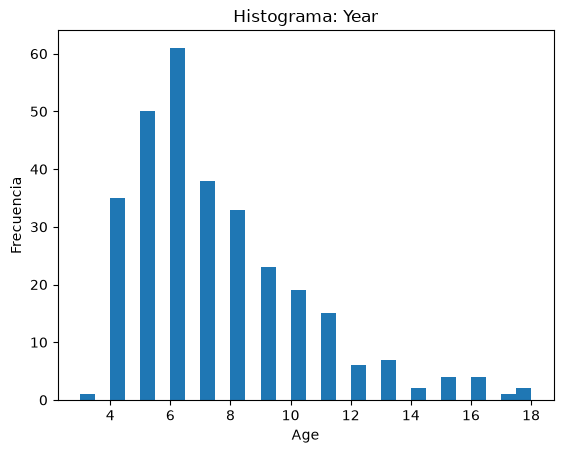

In [ ]:
plt.figure()
plt.hist(df['Age'], bins=30)
plt.title('Histograma: Year')
plt.xlabel('Age')
plt.ylabel('Frecuencia')
plt.show()

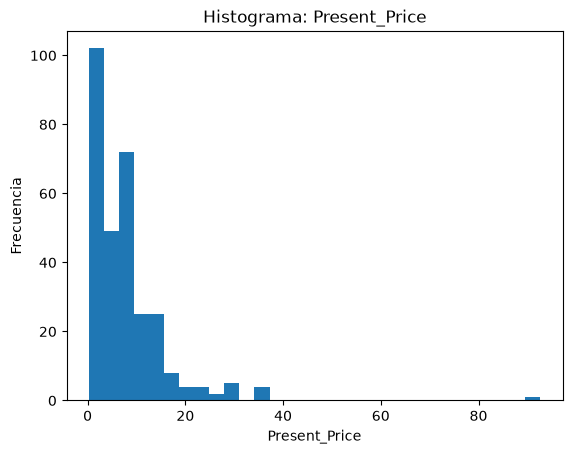

In [ ]:
plt.figure()
plt.hist(df['Present_Price'], bins=30)
plt.title('Histograma: Present_Price')
plt.xlabel('Present_Price')
plt.ylabel('Frecuencia')
plt.show()

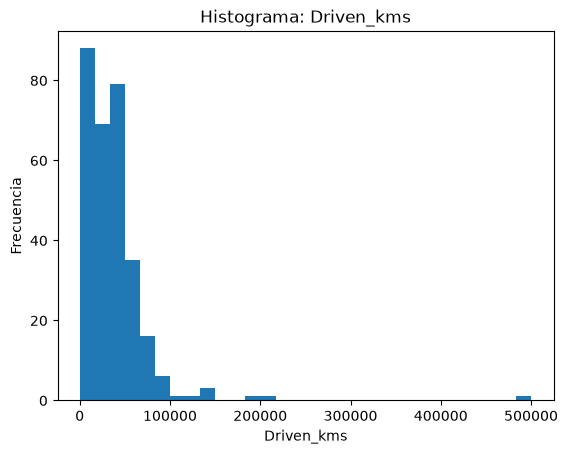

In [ ]:
plt.figure()
plt.hist(df['Driven_kms'], bins=30)
plt.title('Histograma: Driven_kms')
plt.xlabel('Driven_kms')
plt.ylabel('Frecuencia')
plt.show()

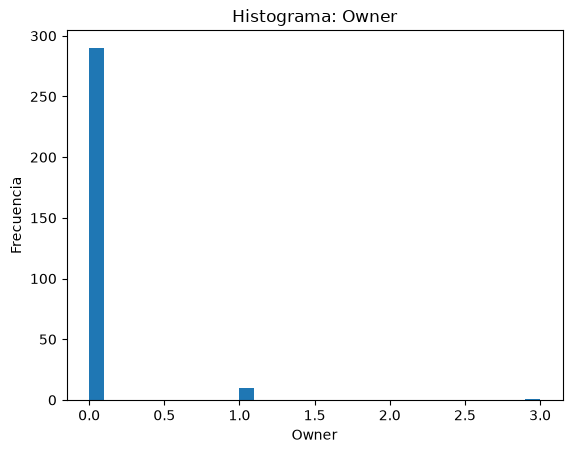

In [ ]:
plt.figure()
plt.hist(df['Owner'], bins=30)
plt.title('Histograma: Owner')
plt.xlabel('Owner')
plt.ylabel('Frecuencia')
plt.show()

## 5) Distribución categórica

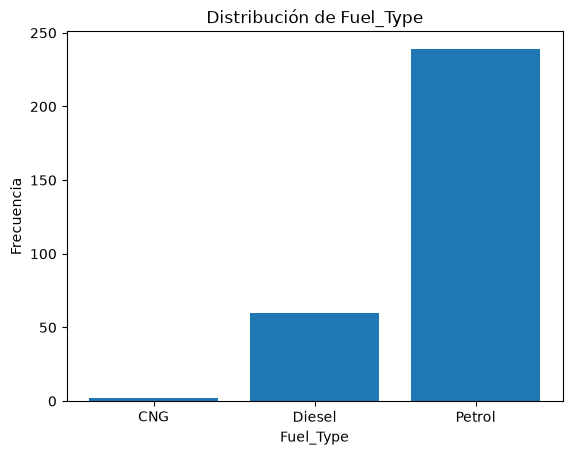

In [ ]:
counts = df['Fuel_Type'].value_counts().sort_index()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Distribución de Fuel_Type')
plt.xlabel('Fuel_Type')
plt.ylabel('Frecuencia')
plt.show()

## 6) Gráficas vs. y (dispersión)

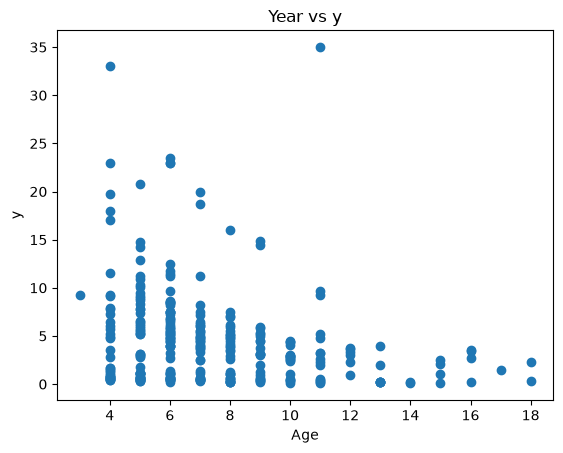

In [ ]:
plt.figure()
plt.scatter(df['Age'], y)
plt.title('Year vs y')
plt.xlabel('Age')
plt.ylabel('y')
plt.show()

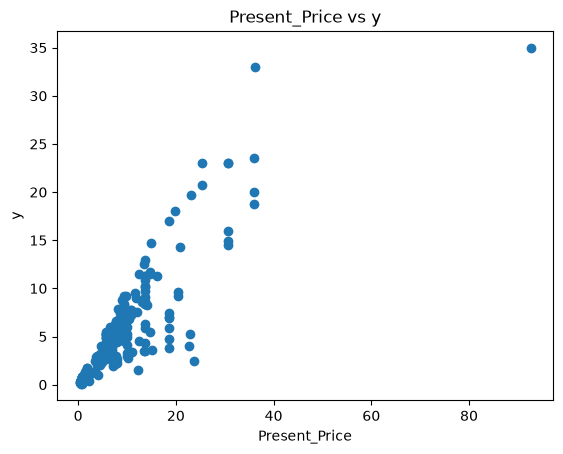

In [ ]:
plt.figure()
plt.scatter(df['Present_Price'], y)
plt.title('Present_Price vs y')
plt.xlabel('Present_Price')
plt.ylabel('y')
plt.show()

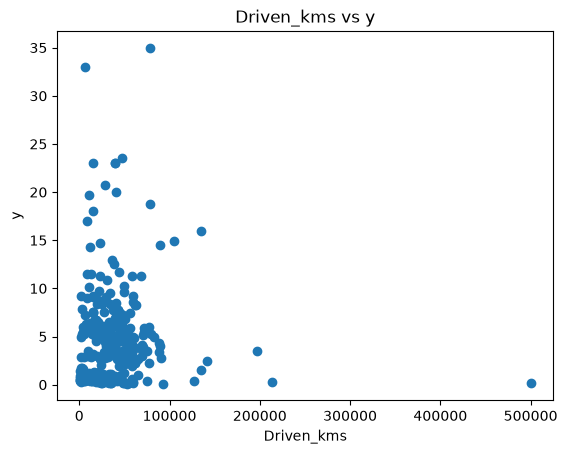

In [ ]:
plt.figure()
plt.scatter(df['Driven_kms'], y)
plt.title('Driven_kms vs y')
plt.xlabel('Driven_kms')
plt.ylabel('y')
plt.show()

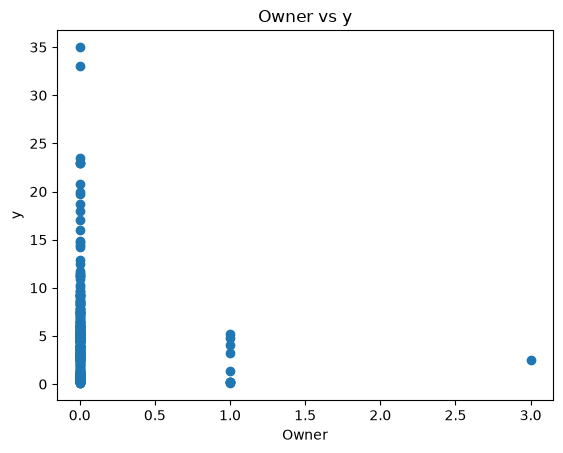

In [ ]:
plt.figure()
plt.scatter(df['Owner'], y)
plt.title('Owner vs y')
plt.xlabel('Owner')
plt.ylabel('y')
plt.show()

## 7) Pipeline + GridSearchCV

In [6]:
from sklearn.preprocessing import FunctionTransformer

categorical = ['Fuel_Type']
numeric     = ['Age', 'Present_Price', 'Driven_kms', 'Owner']

pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', 'passthrough', numeric),
])

pipe = Pipeline([
    ('norm',   _normalize_cols()),
    ('pre',    pre),
    ('select', SelectKBest(score_func=f_regression, k=5)),
    ('scale',  MinMaxScaler()),
    ('reg',    LinearRegression()),
])

gscv = GridSearchCV(
    pipe,
    param_grid={'select__k': [4, 5, 6, 7]},
    cv=10,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
gscv.fit(X_train, y_train)

print('Mejor k:', gscv.best_params_)
print('CV MAE (promedio):', -gscv.best_score_)


Mejor k: {'select__k': 6}
CV MAE (promedio): 1.17472430801015


In [7]:
import os

os.makedirs(str(DIR_MODELS), exist_ok=True)

# Guardar el GridSearchCV completo (no best_estimator_) para que
# model.score() use el scorer neg_mean_absolute_error
with gzip.open(str(MODEL_PATH), 'wb') as f:
    pickle.dump(gscv, f, protocol=pickle.HIGHEST_PROTOCOL)

print('Modelo guardado en:', MODEL_PATH)


Modelo guardado en: c:\Fundamentos\LAB-13-prediccion-de-precios-usando-regresion-lineal-OscarArango1\files\models\model.pkl.gz


In [8]:
best = gscv.best_estimator_

y_pred_tr = best.predict(X_train)
y_pred_te = best.predict(X_test)

m_train = {
    'type': 'metrics', 'dataset': 'train',
    'r2':  round(r2_score(y_train, y_pred_tr), 3),
    'mse': round(mean_squared_error(y_train, y_pred_tr), 3),
    'mad': round(mean_absolute_error(y_train, y_pred_tr), 3),
}
m_test = {
    'type': 'metrics', 'dataset': 'test',
    'r2':  round(r2_score(y_test, y_pred_te), 3),
    'mse': round(mean_squared_error(y_test, y_pred_te), 3),
    'mad': round(mean_absolute_error(y_test, y_pred_te), 3),
}

os.makedirs(str(DIR_OUTPUT), exist_ok=True)
with open(str(METRICS_PATH), 'w', encoding='utf-8') as f:
    f.write(json.dumps(m_train) + '\n')
    f.write(json.dumps(m_test)  + '\n')

print('Train:', m_train)
print('Test: ', m_test)
print('Métricas guardadas en:', METRICS_PATH)


Train: {'type': 'metrics', 'dataset': 'train', 'r2': 0.895, 'mse': 2.419, 'mad': 1.097}
Test:  {'type': 'metrics', 'dataset': 'test', 'r2': 0.76, 'mse': 7.657, 'mad': 1.542}
Métricas guardadas en: c:\Fundamentos\LAB-13-prediccion-de-precios-usando-regresion-lineal-OscarArango1\files\output\metrics.json


## 8) Evaluación

In [9]:
y_pred_tr = gscv.predict(X_train)
y_pred_te = gscv.predict(X_test)
metrics_train = {
    'type': 'metrics','dataset': 'train',
    'r2': float(r2_score(y_train, y_pred_tr)),
    'mse': float(mean_squared_error(y_train, y_pred_tr)),
    'mad': float(mean_absolute_error(y_train, y_pred_tr)),
}
metrics_test = {
    'type': 'metrics','dataset': 'test',
    'r2': float(r2_score(y_test, y_pred_te)),
    'mse': float(mean_squared_error(y_test, y_pred_te)),
    'mad': float(mean_absolute_error(y_test, y_pred_te)),
}
metrics_train, metrics_test

({'type': 'metrics',
  'dataset': 'train',
  'r2': 0.8953608176650663,
  'mse': 2.4188287106478077,
  'mad': 1.0966252211920111},
 {'type': 'metrics',
  'dataset': 'test',
  'r2': 0.7600866803818165,
  'mse': 7.656833006197653,
  'mad': 1.5422228402479103})

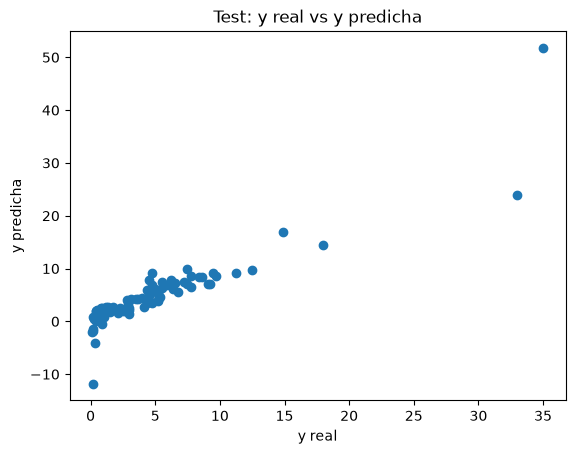

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred_te)
plt.title('Test: y real vs y predicha')
plt.xlabel('y real')
plt.ylabel('y predicha')
plt.show()

## 9) Matriz de correlación (final)

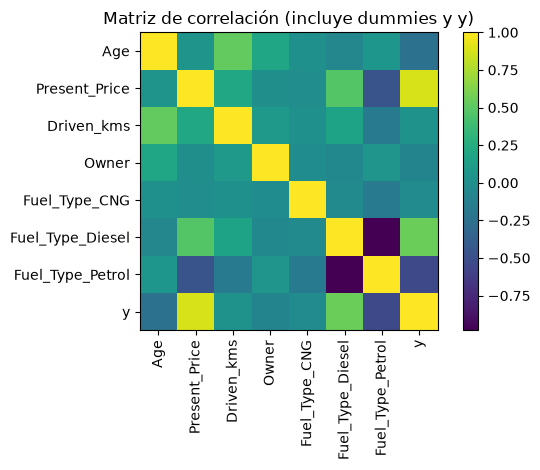

In [ ]:
df_enc = pd.get_dummies(df[['Fuel_Type','Age','Present_Price','Driven_kms','Owner']], drop_first=False)
df_corr = df_enc.copy(); df_corr['y'] = y
corr = df_corr.corr(numeric_only=True)
plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.title('Matriz de correlación (incluye dummies y y)')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.tight_layout()
plt.show()